In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv('customer_churn_dataset.csv')
print(df.head())

  CustomerID               Name  Age  Gender  Subscription_Length  \
0   CUST0001      Julie Ramirez   34    Male                    4   
1   CUST0002      Victoria Yang   48  Female                   41   
2   CUST0003           Jon Hall   61  Female                   17   
3   CUST0004  Christopher Baker   49  Female                   12   
4   CUST0005       Meghan Baker   62    Male                   35   

   Login_Frequency  Support_Contacts  Last_Login_Days  Monthly_Usage_Hours  \
0             48.0                 7               53                 3.33   
1             26.0                13               48                 1.24   
2             47.0                14               60                97.94   
3             43.0                12               11               126.01   
4             13.0                 4               30               179.55   

  Payment_Failed  Feedback_Score Churn  
0             No             2.0   Yes  
1            Yes             4.0  

In [4]:
print(df.isnull().sum())

CustomerID              0
Name                    0
Age                     0
Gender                  0
Subscription_Length     0
Login_Frequency        10
Support_Contacts        0
Last_Login_Days         0
Monthly_Usage_Hours    10
Payment_Failed          0
Feedback_Score         10
Churn                   0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

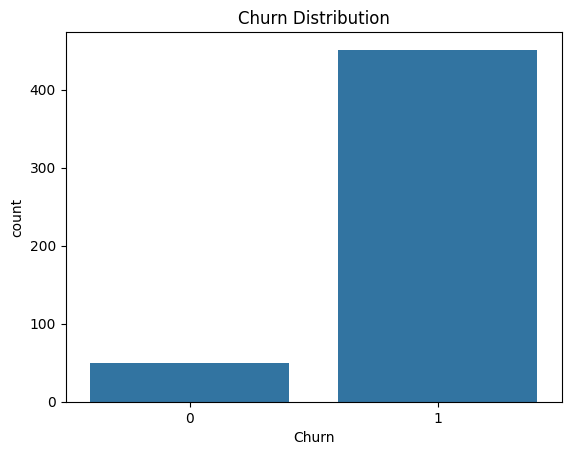

In [7]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

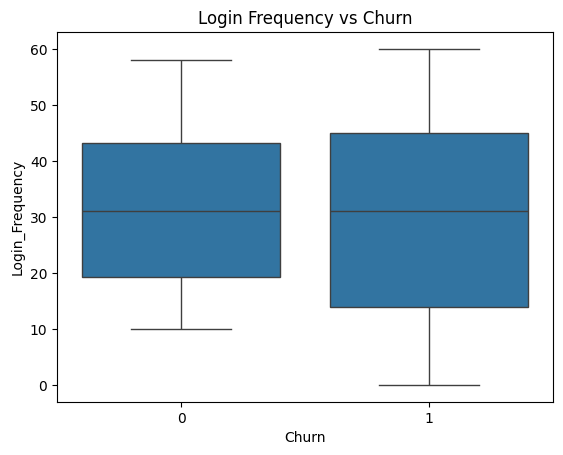

In [8]:
sns.boxplot(x='Churn', y='Login_Frequency', data=df)
plt.title('Login Frequency vs Churn')
plt.show()

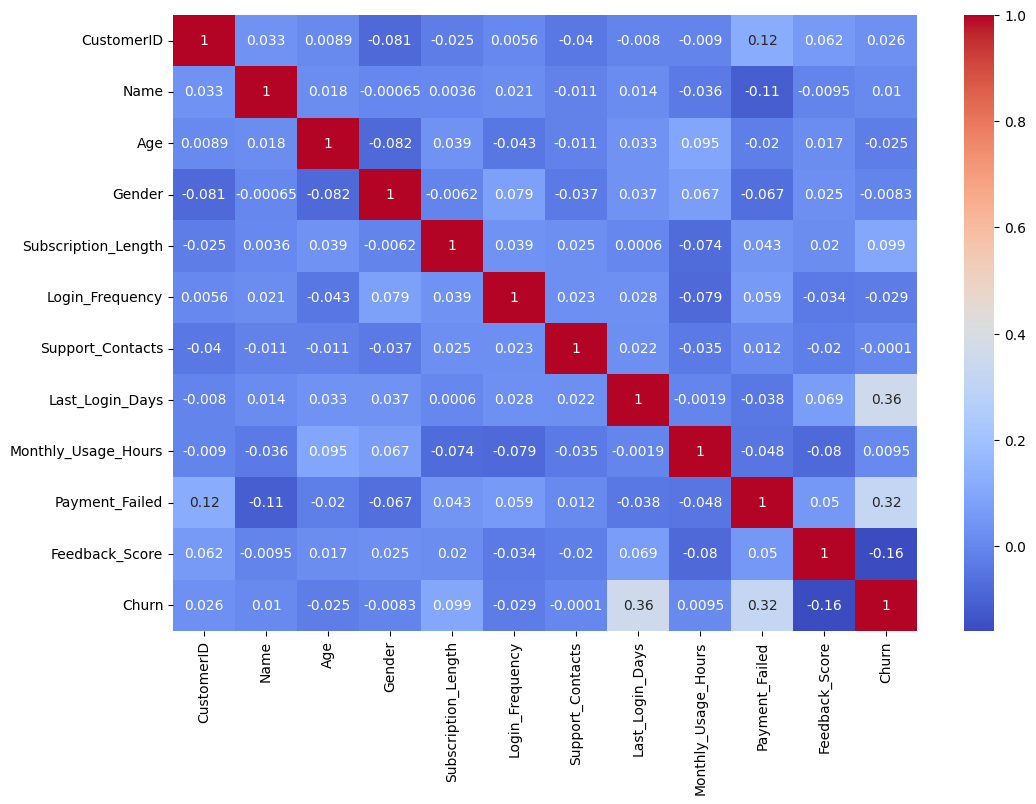

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.99


In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                Feature  Importance
7       Last_Login_Days    0.322455
9        Payment_Failed    0.222339
10       Feedback_Score    0.136420
4   Subscription_Length    0.063724
5       Login_Frequency    0.052261
1                  Name    0.046196
8   Monthly_Usage_Hours    0.045686
2                   Age    0.037095
6      Support_Contacts    0.032675
0            CustomerID    0.032436
3                Gender    0.008713
